# Machine Learning Lab - Assignment 03

**Name:** Abu Bakar Sadiq
### Program : AI "B" 
**Assignment:** Gradient Descent


# part 0

ID = 2450 | freq = 2.0 | sigma = 0.30000000000000004


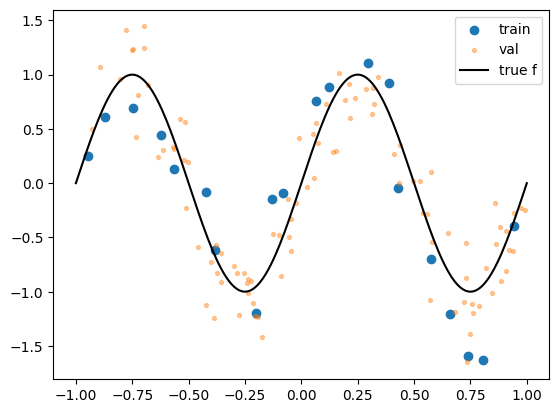

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ID = 2450  # replace with the last 4 digits of your student ID (no leading zero, see note below)
rng = np.random.default_rng(ID)

freq = 1 + (ID % 3) * 0.5      # frequency of the true signal
sigma = 0.20 + (ID % 4) * 0.05 # noise level

def true_f(x):  # expects x in [0, 1]
    return np.sin(2 * np.pi * freq * x)

def make_split(n, spread=False):
    if spread:  # x-values spread evenly, with jitter
        x = (np.arange(n) + rng.uniform(0, 1, n)) / n
    else:
        x = rng.uniform(0, 1, n)
    y = true_f(x) + rng.normal(0, sigma, n)
    return 2 * x - 1, y  # inputs are rescaled to [-1, 1]

x_tr, y_tr   = make_split(20, spread=True)  # training set
x_val, y_val = make_split(100)              # validation set
x_te, y_te   = make_split(200)              # test set

x_plot = np.linspace(-1, 1, 200)            # for plotting the true function
y_true_plot = true_f((x_plot + 1) / 2)

print("ID =", ID, "| freq =", freq, "| sigma =", sigma)

# Sanity check plot
plt.scatter(x_tr, y_tr, label="train")
plt.scatter(x_val, y_val, s=8, alpha=0.4, label="val")
plt.plot(x_plot, y_true_plot, "k", label="true f")
plt.legend(); plt.show()

## Part 1: Predictions¶
A. I expect degree 6 to give the lowest error on unseen data. Reason: the true signal (freq = 2.0) has 4 turning points, so a polynomial needs at least degree 5 to follow it. With only 20 noisy points (sigma = 0.30), going much higher would start fitting the noise, so I predict just above 5.

B. I expect degree 15 to need more epochs than degree 3. Reason: in degree 15 the columns of X are very similar to each other, so the loss surface is a long narrow valley and gradient descent moves slowly. Degree 3 has a simple, well-shaped surface and converges quickly.

Part 2: Gradient Descent From Scratch

In [2]:
def design_matrix(x, degree):
    n = len(x)
    X = np.zeros((n, degree + 1))
    X[:, 0] = 1.0                      # T_0(x) = 1
    if degree >= 1:
        X[:, 1] = x                    # T_1(x) = x
    for k in range(2, degree + 1):
        X[:, k] = 2 * x * X[:, k - 1] - X[:, k - 2]   # recurrence
    return X

## 2a derivation

In [3]:
def mse(X, y, w):
    r = X @ w - y                 # residual: prediction minus target
    return np.mean(r**2)          # (1/n) * sum of squared residuals

def gradient(X, y, w):
    n = len(y)
    r = X @ w - y
    return (2 / n) * (X.T @ r)    # (2/n) * X^T (Xw - y)

In [4]:
def numerical_gradient(X, y, w, h=1e-5):
    g = np.zeros_like(w)
    for i in range(len(w)):
        e = np.zeros_like(w)
        e[i] = h
        g[i] = (mse(X, y, w + e) - mse(X, y, w - e)) / (2 * h)
    return g

X5 = design_matrix(x_tr, 5)
w_rand = np.random.default_rng(0).normal(size=6)   # separate generator, so your dataset stays unchanged

g_a = gradient(X5, y_tr, w_rand)
g_n = numerical_gradient(X5, y_tr, w_rand)
print("analytic:", g_a)
print("numeric :", g_n)
print("max abs difference:", np.max(np.abs(g_a - g_n)))

analytic: [ 0.08436373  0.26888603  0.85152744 -0.03185042 -1.16289482 -0.61169807]
numeric : [ 0.08436373  0.26888603  0.85152744 -0.03185042 -1.16289482 -0.61169807]
max abs difference: 1.626285911493497e-11


In [5]:
def gradient_descent(X, y, lr, max_epochs=20000, tol=1e-6):
    w = np.zeros(X.shape[1])
    for epoch in range(1, max_epochs + 1):
        g = ____                        # current gradient at w
        if ____ < tol:                  # norm of the gradient below tol
            break
        w = ____                        # update rule
    return w, epoch

# 2b. Gradient check (required before continuing)

2b. Gradient check
I compared my analytic gradient (2/n) * X^T (Xw - y) with a numerical gradient (central differences, h = 1e-5) for degree 5 at a random w.

Result: the largest absolute difference is 1.63e-11. This is far below 1e-6, so my gradient is correct and I can continue.

In [7]:
X5 = design_matrix(x_tr, 5)
w_rand = np.random.default_rng(0).normal(size=6)

g_a = gradient(X5, y_tr, w_rand)
g_n = numerical_gradient(X5, y_tr, w_rand)
print("analytic:", g_a)
print("numeric :", g_n)
print("max abs difference:", np.max(np.abs(g_a - g_n)))

analytic: [ 0.08436373  0.26888603  0.85152744 -0.03185042 -1.16289482 -0.61169807]
numeric : [ 0.08436373  0.26888603  0.85152744 -0.03185042 -1.16289482 -0.61169807]
max abs difference: 1.626285911493497e-11


In [8]:
def gradient_descent(X, y, lr, max_epochs=20000, tol=1e-6):
    w = np.zeros(X.shape[1])
    for epoch in range(1, max_epochs + 1):
        g = gradient(X, y, w)              # slope of the loss at the current w
        if np.linalg.norm(g) < tol:        # gradient almost zero, so we converged
            break                          # stop early
        w = w - lr * g                     # step downhill
    return w, epoch

In [9]:
lrs = [0.001, 0.01, 0.1, 0.5, 2]

for deg in [3, 15]:
    X = design_matrix(x_tr, deg)
    print(f"Degree {deg}, max_epochs=3000")
    for lr in lrs:
        with np.errstate(all="ignore"):       # hides overflow warnings when diverging
            w, ep = gradient_descent(X, y_tr, lr, max_epochs=3000)
            loss = mse(X, y_tr, w)
        if (not np.isfinite(loss)) or loss > 1e6:
            status = "diverges"
        elif ep < 3000:
            status = "converges"
        else:
            status = "hit the cap (slow, but stable)"
        print(f"  lr={lr:<6} epochs={ep:<5} train MSE={loss:.4f} -> {status}")

Degree 3, max_epochs=3000
  lr=0.001  epochs=3000  train MSE=0.4609 -> hit the cap (slow, but stable)
  lr=0.01   epochs=3000  train MSE=0.4364 -> hit the cap (slow, but stable)
  lr=0.1    epochs=360   train MSE=0.4364 -> converges
  lr=0.5    epochs=68    train MSE=0.4364 -> converges
  lr=2      epochs=3000  train MSE=nan -> diverges
Degree 15, max_epochs=3000
  lr=0.001  epochs=3000  train MSE=0.0267 -> hit the cap (slow, but stable)
  lr=0.01   epochs=3000  train MSE=0.0215 -> hit the cap (slow, but stable)
  lr=0.1    epochs=3000  train MSE=0.0214 -> hit the cap (slow, but stable)
  lr=0.5    epochs=3000  train MSE=0.0210 -> hit the cap (slow, but stable)
  lr=2      epochs=3000  train MSE=nan -> diverges


### 2c. Learning rate results (max_epochs = 3000)

**Degree 3**

| lr | Epochs | Train MSE | Verdict |
|---|---|---|---|
| 0.001 | 3000 | 0.4609 | very slow (still above 0.4364) |
| 0.01 | 3000 | 0.4364 | slow (reaches the loss but not the tolerance in 3000 epochs) |
| 0.1 | 360 | 0.4364 | converges |
| 0.5 | 68 | 0.4364 | converges (fastest) |
| 2 | 3000 | nan | diverges |

**Degree 15**

| lr | Epochs | Train MSE | Verdict |
|---|---|---|---|
| 0.001 | 3000 | 0.0267 | stable, but slow (hits the cap) |
| 0.01 | 3000 | 0.0215 | stable, but slow (hits the cap) |
| 0.1 | 3000 | 0.0214 | stable, but slow (hits the cap) |
| 0.5 | 3000 | 0.0210 | stable, but slow (hits the cap) |
| 2 | 3000 | nan | diverges |

**Conclusion:** for degree 15, the rates 0.001, 0.01, 0.1 and 0.5 are stable and lr = 2 diverges. I will use **lr = 0.5** for Part 3, since it is the largest rate that is stable for degree 15.

Part 4: Measuring Bias and Variance

In [10]:
def make_train_set(seed, n=20):
    r = np.random.default_rng(seed)
    x = (np.arange(n) + r.uniform(0, 1, n)) / n
    y = true_f(x) + r.normal(0, sigma, n)
    return 2 * x - 1, y

seeds = [ID * 100 + k for k in range(5)]
x_grid = np.linspace(-1, 1, 100)
true_grid = true_f((x_grid + 1) / 2)

In [11]:
LR = 0.5
degrees_b = [1, 3, 15]
preds_all = {}
bv = []

for deg in degrees_b:
    X_grid = design_matrix(x_grid, deg)
    preds = []
    for s in seeds:
        xs, ys = make_train_set(s)
        Xs = design_matrix(xs, deg)
        w, ep = gradient_descent(Xs, ys, LR, max_epochs=20000)
        preds.append(X_grid @ w)
    preds = np.array(preds)
    preds_all[deg] = preds

    mean_pred = preds.mean(axis=0)
    bias2    = np.mean((mean_pred - true_grid) ** 2)
    variance = np.mean(np.var(preds, axis=0))
    bv.append((deg, bias2, variance))
    print(f"degree {deg:<2} Bias^2={bias2:.4f}  Variance={variance:.4f}")

degree 1  Bias^2=0.4228  Variance=0.0107
degree 3  Bias^2=0.3704  Variance=0.0175
degree 15 Bias^2=1.1482  Variance=4.8410


### 4a. Bias and variance (5 training sets, lr = 0.5, max_epochs = 20000)

| Degree | Bias² | Variance |
|---|---|---|
| 1 | 0.4228 | 0.0107 |
| 3 | 0.3704 | 0.0175 |
| 15 | 1.1482 | 4.8410 |

## 4b

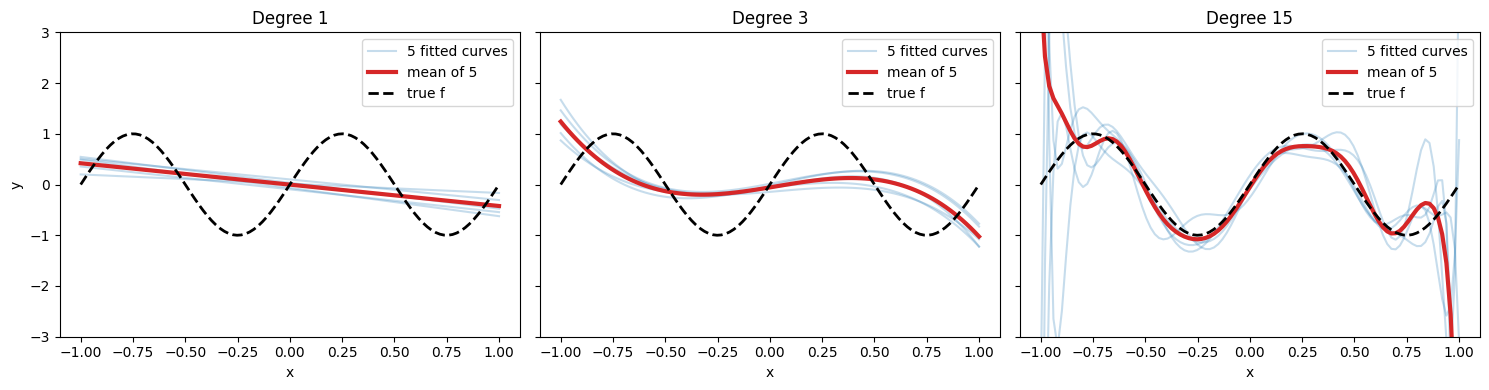

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, deg in zip(axes, [1, 3, 15]):
    preds = preds_all[deg]                       # shape (5, 100)
    for k in range(5):
        ax.plot(x_grid, preds[k], color="tab:blue", alpha=0.25,
                label="5 fitted curves" if k == 0 else None)
    ax.plot(x_grid, preds.mean(axis=0), color="tab:red", lw=3, label="mean of 5")
    ax.plot(x_grid, true_grid, "k--", lw=2, label="true f")
    ax.set_ylim(-3, 3)                           # same y-limits in all panels
    ax.set_title(f"Degree {deg}")
    ax.set_xlabel("x")
    ax.legend(loc="upper right")

axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

# part 5b

In [14]:
def gradient_bad(X, y, w):
    n = len(y)
    return (2 / n) * X.T @ (y - X @ w)

g_bad = gradient_bad(X5, y_tr, w_rand)
g_num = numerical_gradient(X5, y_tr, w_rand)
print("max abs difference (buggy):", np.max(np.abs(g_bad - g_num)))

max abs difference (buggy): 2.325789636008383


### Part 5: Debugging

**1. The bug.** The function uses (y - X w), but the correct residual is (X w - y).
Since y - Xw = -(Xw - y), the function returns the negative of the true gradient.
In the update w <- w - lr * grad, this becomes w <- w + lr * g, which moves w
uphill (gradient ascent), so the loss increases at every step.

**2. Would my gradient check catch it?** Yes. The numerical gradient measures the
true slope g, while the buggy function returns -g, so every entry differs by |2g|.
When I ran my check with the buggy function, the max absolute difference was 2.33,
far above the 1e-6 threshold (my correct gradient gave 1.6e-11). The check would
report a failure.

In [16]:
LR = 0.5
results = []          # one row per degree

for deg in range(1, 16):
    X_tr_d  = design_matrix(x_tr,  deg)
    X_val_d = design_matrix(x_val, deg)
    X_te_d  = design_matrix(x_te,  deg)

    w, ep = gradient_descent(X_tr_d, y_tr, LR, max_epochs=20000)

    train_mse = mse(X_tr_d,  y_tr,  w)     # error on the data the model learned from
    val_mse   = mse(X_val_d, y_val, w)     # error on validation data (used to choose the degree)
    test_mse  = mse(X_te_d,  y_te,  w)     # error on test data (final report only)
    w_norm    = np.linalg.norm(w)          # size of the weights

    results.append((deg, ep, train_mse, val_mse, test_mse, w_norm))
    print(f"deg={deg:<2} epochs={ep:<6} train={train_mse:.4f} val={val_mse:.4f} test={test_mse:.4f} |w|={w_norm:.3f}")

deg=1  epochs=34     train=0.5325 val=0.5204 test=0.4881 |w|=0.663
deg=2  epochs=38     train=0.4968 val=0.5964 test=0.5257 |w|=0.767
deg=3  epochs=68     train=0.4364 val=0.5378 test=0.4464 |w|=1.111
deg=4  epochs=74     train=0.4048 val=0.5464 test=0.4934 |w|=1.068
deg=5  epochs=105    train=0.0667 val=0.2241 test=0.2260 |w|=1.167
deg=6  epochs=106    train=0.0645 val=0.2388 test=0.2250 |w|=1.168
deg=7  epochs=180    train=0.0428 val=0.1814 test=0.2020 |w|=1.059
deg=8  epochs=325    train=0.0428 val=0.1823 test=0.2019 |w|=1.064
deg=9  epochs=762    train=0.0351 val=0.2530 test=0.2345 |w|=1.273
deg=10 epochs=1987   train=0.0351 val=0.2419 test=0.2325 |w|=1.244
deg=11 epochs=4906   train=0.0349 val=0.2082 test=0.2192 |w|=1.106
deg=12 epochs=20000  train=0.0324 val=0.7969 test=0.3807 |w|=2.855
deg=13 epochs=20000  train=0.0254 val=1.3369 test=1.6768 |w|=6.482
deg=14 epochs=20000  train=0.0243 val=2.9375 test=1.1046 |w|=6.982
deg=15 epochs=20000  train=0.0189 val=0.2308 test=1.7081 |w|=5

## 3a table

### 3a. Complexity sweep (lr = 0.5, max_epochs = 20000)

| Degree | Epochs | Train MSE | Val MSE | Test MSE | ‖w‖₂ |
|---|---|---|---|---|---|
| 1 | 34 | 0.5325 | 0.5204 | 0.4881 | 0.663 |
| 3 | 68 | 0.4364 | 0.5378 | 0.4464 | 1.111 |
| 5 | 105 | 0.0667 | 0.2241 | 0.2260 | 1.167 |
| 9 | 762 | 0.0351 | 0.2530 | 0.2345 | 1.273 |
| 15 | 20000 | 0.0189 | 0.2308 | 1.7081 | 5.15 |

Best degree by validation MSE: 7 (val 0.1814, test 0.2020).

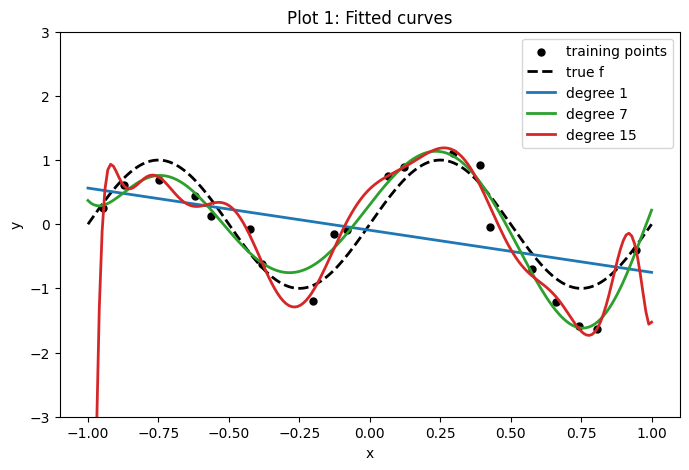

In [17]:
best_deg = 7                                   # chosen from validation MSE

plt.figure(figsize=(8, 5))
plt.scatter(x_tr, y_tr, color="black", s=25, label="training points")
plt.plot(x_plot, y_true_plot, "k--", lw=2, label="true f")

for deg, col in [(1, "tab:blue"), (best_deg, "tab:green"), (15, "tab:red")]:
    w, ep = gradient_descent(design_matrix(x_tr, deg), y_tr, 0.5, max_epochs=20000)
    y_hat = design_matrix(x_plot, deg) @ w      # fitted curve on the plotting grid
    plt.plot(x_plot, y_hat, color=col, lw=2, label=f"degree {deg}")

plt.ylim(-3, 3)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Plot 1: Fitted curves")
plt.legend(); plt.show()